CASCADE - CLASSIFICATION -> REGRESSOR

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Import Classifier (Untuk tebak kelas) dan Regressor (Untuk tebak angka)
from sklearn.svm import SVC, SVR

# Import metrik evaluasi
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Total data pasien: 211


,Country,Subject_ID,Age,Gender,mean_R,mean_G,mean_B,mean_L,mean_a,mean_b,mean_H,mean_S,mean_V,Hemoglobin,Anemia_Class
0,India,1,29,M,165.681334,82.346387,124.941774,118.559390,166.313710,124.941774,166.367962,130.298180,165.700354,12.2,2
1,India,2,36,F,159.608875,105.623553,119.549809,130.963319,154.832061,119.549809,160.096852,89.443007,160.550162,8.0,1
2,India,3,30,F,142.347389,81.613713,122.984434,108.931662,157.473051,122.984434,164.515150,112.148609,142.947018,10.7,1
3,India,4,39,F,172.217661,131.992063,115.307618,152.968773,149.983883,115.307618,150.293604,71.055925,178.894736,8.3,1
4,India,5,29,F,152.483330,82.745516,123.574996,113.115925,160.959679,123.574996,165.402269,118.849228,152.626490,7.8,0



=== DISTRIBUSI KELAS ANEMIA ===


,Jumlah Subjek
Anemia_Class,
Normal (3),121
Mild (2),37
Moderate (1),50
Severe (0),3


C:\Users\dzakw\AppData\Local\Temp\ipykernel_34728\570480725.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


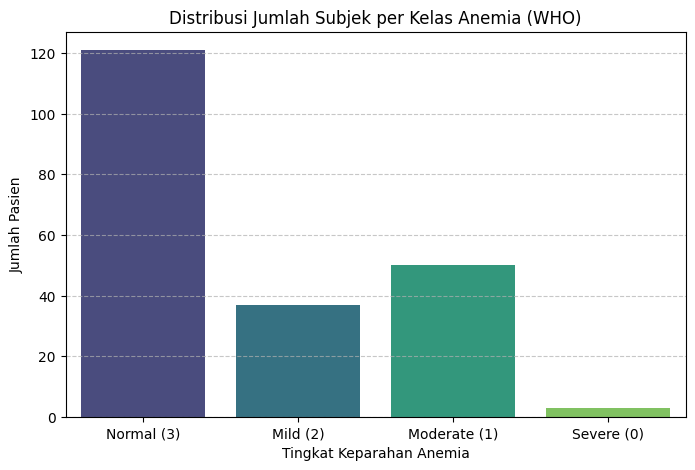

In [16]:
# =====================================================================
# 1. PERSIAPAN DATA 
# =====================================================================
EXCEL_PATH = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\hasil_ekstraksi_fitur.xlsx' 
df = pd.read_excel(EXCEL_PATH)

print(f"Total data pasien: {len(df)}")
display(df.head())

# Membersihkan data dari nilai kosong (jika ada)
df = df.dropna(subset=['Anemia_Class', 'Hemoglobin', 'Age', 'Gender'])

# =====================================================================
# 1.5. ANALISIS DISTRIBUSI KELAS ANEMIA (Saran Dosen)
# =====================================================================
print("\n=== DISTRIBUSI KELAS ANEMIA ===")
# Menghitung jumlah untuk setiap kelas
class_counts = df['Anemia_Class'].value_counts().sort_index(ascending=False)

# Memetakan angka ke nama kelas untuk tampilan yang lebih mudah dibaca
class_names = {3.0: 'Normal (3)', 2.0: 'Mild (2)', 1.0: 'Moderate (1)', 0.0: 'Severe (0)'}
class_counts.index = class_counts.index.map(class_names)

# Menampilkan tabel distribusi
display(class_counts.to_frame(name='Jumlah Subjek'))

# Menampilkan grafik visualisasi (Bar Chart)
plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribusi Jumlah Subjek per Kelas Anemia (WHO)')
plt.xlabel('Tingkat Keparahan Anemia')
plt.ylabel('Jumlah Pasien')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# =====================================================================
# 1. PERSIAPAN DATA (Splitting 3 Variabel Sekaligus)
# =====================================================================
# Pastikan DataFrame 'df' sudah dimuat sebelumnya dari file Excel
feature_columns = ['Age', 'Gender', 'mean_R', 'mean_G', 'mean_B', 'mean_L', 'mean_a', 'mean_b', 'mean_H', 'mean_S', 'mean_V']
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0, 'Male': 1, 'Female': 0})

X = df[feature_columns]
y_class = df['Anemia_Class'] # Target Tahap 1 (0, 1, 2, atau 3)
y_hb = df['Hemoglobin']      # Target Tahap 2 (misal: 11.2, 8.5)

# Membagi data menjadi Training dan Testing. 
# KITA HARUS MEMBAGI KETIGANYA BERSAMAAN agar indeks barisnya tidak acak/tertukar.
X_train, X_test, y_class_train, y_class_test, y_hb_train, y_hb_test = train_test_split(
    X, y_class, y_hb, test_size=0.2, random_state=42)

In [11]:
# =====================================================================
# 2. TAHAP 1: MELATIH MODEL KLASIFIKASI (SVC)
# =====================================================================
print("--- [TAHAP 1] MELATIH MODEL KLASIFIKASI KELAS ANEMIA ---")
# Membuat pipeline StandardScaler + Support Vector Classifier
classifier_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, probability=True, random_state=42))

# Melatih model HANYA menggunakan 11 fitur untuk menebak 'y_class'
classifier_model.fit(X_train, y_class_train)

# Evaluasi kehebatan model klasifikasi
class_pred_test = classifier_model.predict(X_test)
acc = accuracy_score(y_class_test, class_pred_test)
print(f"Akurasi Tebakan Kelas Anemia (Tahap 1): {acc * 100:.2f}%")
print(classification_report(y_class_test, class_pred_test, zero_division=0))

--- [TAHAP 1] MELATIH MODEL KLASIFIKASI KELAS ANEMIA ---
Akurasi Tebakan Kelas Anemia (Tahap 1): 79.07%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.53      1.00      0.70         8
           2       0.67      0.33      0.44         6
           3       0.96      0.86      0.91        28

    accuracy                           0.79        43
   macro avg       0.54      0.55      0.51        43
weighted avg       0.82      0.79      0.78        43



In [12]:
# =====================================================================
# 3. PERSIAPAN DATA UNTUK TAHAP 2 (MENGGABUNGKAN FITUR)
# =====================================================================
# Agar Tahap 2 realistis, kita TIDAK BOLEH memasukkan kunci jawaban asli 'y_class'.
# Kita harus menggunakan KELAS HASIL TEBAKAN (Prediksi) dari Model Tahap 1.

# Menyuruh Model 1 menebak kelas untuk data Training dan Testing
predicted_class_train = classifier_model.predict(X_train)
predicted_class_test = classifier_model.predict(X_test)

# Membuat copy dari X_train dan X_test agar tidak merusak data asli
X_train_stage2 = X_train.copy()
X_test_stage2 = X_test.copy()

# Menambahkan KELAS HASIL TEBAKAN sebagai fitur ke-12
X_train_stage2['Predicted_Class'] = predicted_class_train
X_test_stage2['Predicted_Class'] = predicted_class_test

In [13]:
# =====================================================================
# 4. TAHAP 2: MELATIH MODEL REGRESI (SVR)
# =====================================================================
print("\n--- [TAHAP 2] MELATIH MODEL REGRESI ANGKA HEMOGLOBIN ---")
# Membuat pipeline StandardScaler + Support Vector Regressor
regressor_model = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1.0, gamma='scale'))

# Melatih SVR menggunakan 12 FITUR (X_train_stage2) untuk menebak 'y_hb_train'
regressor_model.fit(X_train_stage2, y_hb_train)

# Mengevaluasi model SVR pada data Testing (X_test_stage2)
hb_pred_test = regressor_model.predict(X_test_stage2)

mae = mean_absolute_error(y_hb_test, hb_pred_test)
r2 = r2_score(y_hb_test, hb_pred_test)

print(f"Rata-rata Error / MAE (Tahap 2) : {mae:.3f} g/dL")
print(f"R2 Score (Kecocokan)            : {r2:.3f}")


--- [TAHAP 2] MELATIH MODEL REGRESI ANGKA HEMOGLOBIN ---
Rata-rata Error / MAE (Tahap 2) : 1.110 g/dL
R2 Score (Kecocokan)            : 0.574


In [ ]:
# =====================================================================
# 5. MENYIMPAN KEDUA MODEL (WEIGHTS)
# =====================================================================
save_dir = '../models/weights/'
os.makedirs(save_dir, exist_ok=True)

# Menyimpan Model Klasifikasi (Tahap 1)
clf_path = os.path.join(save_dir, 'classifier_model.pkl')
joblib.dump(classifier_model, clf_path)

# Menyimpan Model Regresi (Tahap 2)
reg_path = os.path.join(save_dir, 'regressor_model.pkl')
joblib.dump(regressor_model, reg_path)

print(f"\n[BERHASIL] Kedua model telah disimpan!")
print(f"1. Model Klasifikasi: {clf_path}")
print(f"2. Model Regresi    : {reg_path}")